# How to use the heavy ion hard probes format

Data have been released in a heavy ion hard probes format (**HIONHPOD**) for ***ATLAS*** Open Data for research. This notebook will demonstrate accessing events and variables in these datasets.

First, we will need to install `atlasopenmagic`, allowing us to access these data in python.

In [1]:
import sys
import os.path
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.6.7', 'awkward-pandas>=2023.8.0', 'coffea~=0.7.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook<7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex~=3.1.0', 'vector>=1.4.1']
  Using cached ipykernel-6.31.0-py3-none-any.whl.metadata (4.5 kB)
INFO: pip is looking at multiple versions of coffea to determine which version is compatible with other requirements. This could take a while.
  Using cached coffea-0.7.30-py2.py3-none-any.whl.metadata (9.6 k

In [2]:
# Import basic libraries
import copy
import os

# In case any of these imports fails, please restart the jupyter kernel and try again - it is likely the environment just needs to be updated
import requests
import uproot   # handle ROOT files
import awkward as ak    # nested, variable sized data arrays
import vector   # Lorentz vectors
vector.register_awkward()
import matplotlib.pyplot as plt # plotting
from tqdm import tqdm   # progress bars
import atlasopenmagic as atom   # ATLAS Open Data

## Finding data

By default, the `atlasopenmagic` package is set to proton-proton data for research (`2024r-pp`). We would like the heavy ion hard probes release, so we call `atom.set_release()` to switch over.

In [3]:
atom.set_release("2024r-hi") #TODO Switch over to hard probes when ready

Fetching and caching all metadata for release: 2024r-hi...
Successfully cached 2 datasets.
Active release: 2024r-hi. (Datasets path: REMOTE)


We will use a dataset from _dataset_.

**wip: mc16_5TeV_MC_420000_Hijing_PbPb_5p02TeV_MinBias_Flow_JJFV6**

We can retrieve it by first getting all the urls corresponding to the *dataset identifier* 420000. There are two choices of streaming protocol, either **xrootd** (`protocol='root'`) or **https**. In this case, we will use https for simplicity, however streaming should be faster with xrootd!

In [4]:
urls_sample = atom.get_urls(420000,protocol="https",cache=True)
urls_sample[:5]

['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/mc16_5TeV/DAOD_HION14.41691927._000001.pool.root.1',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/mc16_5TeV/DAOD_HION14.41691927._000002.pool.root.1',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/mc16_5TeV/DAOD_HION14.41691927._000003.pool.root.1',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/mc16_5TeV/DAOD_HION14.41691927._000004.pool.root.1',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/mc16_5TeV/DAOD_HION14.41691927._000005.pool.root.1']

For simplicity, let's just use the first file.

In [5]:
filename = urls_sample[0]
filename

'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/mc16_5TeV/DAOD_HION14.41691927._000001.pool.root.1'

## Reading the HIONHPOD format with uproot

We now have the path to a `TFile`. We can open this file using `uproot.open`, revealing the `TTree` objects within, which we can check with the `.keys()` method.

In [6]:
print("TTree objects inside the ROOT file:")
for key in uproot.open(filename).keys():
    print("-",key)

TTree objects inside the ROOT file:
- ##Params;2
- ##Params;1
- ##Shapes;2
- ##Shapes;1
- ##Links;2
- ##Links;1
- CollectionTree;1
- POOLContainer;1
- POOLContainerForm;1
- POOLCollectionTree;1
- MetaData;1
- MetaDataHdr;1
- MetaDataHdrForm;1


All of our variables for analysis are stored in the `CollectionTree`, which we are able to open directly by passing a `{filename: treename}` dictionary.

In [7]:
tree = uproot.open({filename: "CollectionTree"})

### List branches
Data in the HIONHPOD format are stored in branches including 'AuxDyn' in their name, typically of type `vector<int>` or `vector<float>` (a vector of integers or a vector of floats). We can see all branches in the tree with `.show()`; here we show the first 10 branches. We can also pass a few extra arguments to this method for a more aesthetic readout.

In [8]:
first_ten_branches = list(tree.keys())[:10]
tree.show(filter_name=first_ten_branches,name_width=50,typename_width=50,interpretation_width=50)

name                                               | typename                                           | interpretation                                    
---------------------------------------------------+----------------------------------------------------+---------------------------------------------------
EventInfoAux.                                      | xAOD::AuxInfoBase                                  | AsStridedObjects(Model_xAOD_3a3a_AuxInfoBase_v1)
CaloSumsAux.                                       | xAOD::AuxContainerBase                             | AsStridedObjects(Model_xAOD_3a3a_AuxContainerBa...
CombinedMuonTrackParticlesAux.                     | xAOD::AuxContainerBase                             | AsStridedObjects(Model_xAOD_3a3a_AuxContainerBa...
ExtrapolatedMuonTrackParticlesAux.                 | xAOD::AuxContainerBase                             | AsStridedObjects(Model_xAOD_3a3a_AuxContainerBa...
InDetTrackParticlesAux.                            | xAOD::A

### Load branches into awkward and numpy arrays
We get the branch of a TTree using `[branch_name]` and call `.array()` to read it as an array.

In [11]:
mu_pt = tree["MuonsAuxDyn.pt"].array()

These vector branches are represented using awkward arrays. Here, we got the transverse momentum ($p_\mathrm{T}$) of all the muons in every event. We therefore have a variable number of muons in each event (e.g. some elements of this array may even be empty where no muons are in the event), totalling 14,000 events.

In [12]:
mu_pt

<Array [[], [...], ..., [2.76e+03, ..., 2.11e+03]] type='14000 * var * float32'>

> Note: `14000 * var * float32` implies: 14,000 events, consisting of arrays of variable length (including empty/zero length), and comprising floats (for the $p_\mathrm{T}$ of the muons in a given event).

We can flatten the array into a one-dimensional array to plot its distribution:

In [23]:
mu_pt_np = ak.flatten(mu_pt).to_numpy()
print(f"Total number of muons in 14,000 events: {len(mu_pt_np):,}")
mu_pt_np

Total number of muons in 14,000 events: 16,550


array([4624.7476, 2911.6787, 4600.75  , ..., 2763.83  , 2154.1265,
       2109.3433], dtype=float32)

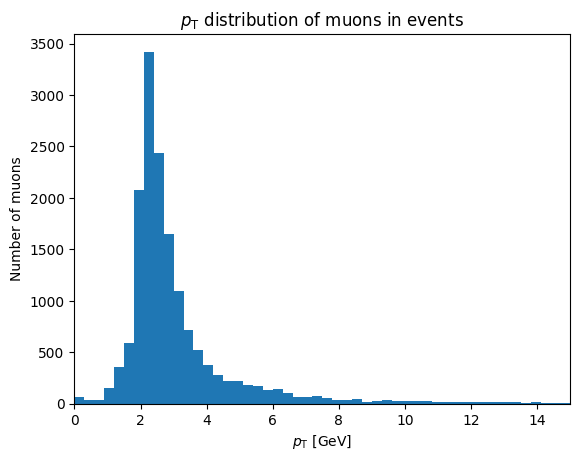

In [45]:
plt.hist(mu_pt_np*1e-3,range=(0,15),bins=50) # Convert pT to GeV (default MeV), plot around maximum peak
plt.xlim(0,15)
plt.title(r"$p_\mathrm{T}$ distribution of muons in events")
plt.xlabel(r"$p_\mathrm{T}$ [GeV]")
plt.ylabel("Number of muons")
plt.show()